# Load and preprocess data

In [67]:
with open("top_english_words_lower_50000.txt", 'r') as words_file:
    words = words_file.read().splitlines()

In [68]:
ALPHABET = "abcdefghijklmnopqrstuvwxyz"

def is_latin(word):
    return all(c in ALPHABET for c in word)

def norm(word):
    return word.lower()

long = filter(lambda w: len(w) > 3, words)
normalized = map(norm, long)
alpha = filter(is_latin, normalized)

words = list(alpha)

In [69]:
import random

random.seed(42)
random.shuffle(words)

In [70]:
stoi = {s: i for i, s in enumerate(ALPHABET, start=1)}
stoi["."] = 0
itos = {v: k for k, v in stoi.items()}

In [71]:
import torch
from more_itertools import windowed

def encode_word(word, prev_tokens):
    def _encode(wrd):
        return [stoi[w] for w in wrd]
    prefix_word = "." * prev_tokens + word
    suffix_word = word + "."
    return list(windowed(_encode(prefix_word), prev_tokens)), _encode(suffix_word)

def encode_words(words, prev_tokens):
    X = []
    Y = []
    for word in words:
        x, y = encode_word(word, prev_tokens)
        X.extend(x)
        Y.extend(y)

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

In [72]:
a = int(0.8 * len(words))
b = int(0.9 * len(words))

# Datasets

In [73]:
PREV_TOKENS = 3

X_train, Y_train = encode_words(words[:a], PREV_TOKENS)
X_valid, Y_valid = encode_words(words[a:b], PREV_TOKENS)
X_test, Y_test = encode_words(words[b:], PREV_TOKENS)

### Model Params and finding best learning rate

In [74]:
GEN = torch.Generator().manual_seed(42)

N_EMBEDDINGS = 2
N_CHARS = len(ALPHABET + ".")
N_NEURONS = 100

embeddings = torch.randn(size=(N_CHARS, N_EMBEDDINGS), generator=GEN)
w1 = torch.randn(size=(N_EMBEDDINGS * PREV_TOKENS, N_NEURONS), generator=GEN)
b1 = torch.randn(N_NEURONS, generator=GEN)
w2 = torch.randn(size=(N_NEURONS, N_CHARS), generator=GEN)
b2 = torch.randn(N_CHARS, generator=GEN)

parameters = [embeddings, w1, b1, w2, b2]
for param in parameters:
    param.requires_grad_()
f"Params: {sum(p.numel() for p in parameters)}"

'Params: 3481'

In [75]:
LEARNING_RATE = 0.01
EPOCHS = 1000
BATCH_SIZE = 128

In [76]:
lr_exponent = torch.linspace(-4, 1, EPOCHS)
lrs = torch.pow(10, lr_exponent)
lr_loss = []

In [77]:
import torch.nn.functional as F

for epoch in range(EPOCHS):
    batch_idx = torch.randint(0, X_valid.shape[0], (BATCH_SIZE, ))
    X_batch = X_valid[batch_idx]
    Y_batch = Y_valid[batch_idx]

    hidden = (embeddings[X_batch].view(-1, 6) @ w1 + b1).tanh()
    logits = (hidden @ w2 + b2)
    loss = F.cross_entropy(logits, Y_batch)

    lr_loss.append(loss.item())

    for param in parameters:
        param.grad = None
    loss.backward()

    for param in parameters:
        assert param.grad is not None, "Need to call backward() on loss"
        with torch.no_grad():
            param.sub_(lrs[epoch] * param.grad)

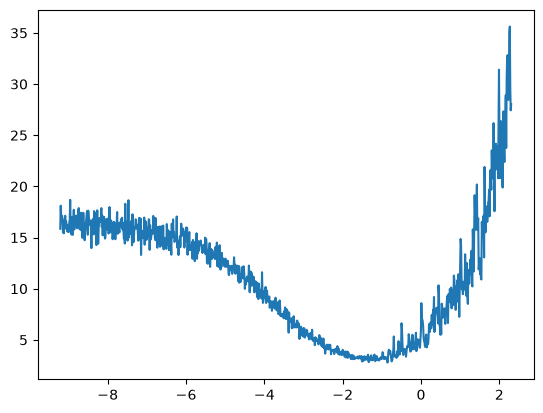

In [78]:
import matplotlib.pyplot as plt

plt.plot(lrs.log(), lr_loss)

looks like best learning rate in this scenario is around $0.1$

In [79]:
def plt_2d_embeddings(embeddings):
    plt.figure(figsize=(8, 8))
    plt.scatter(embeddings[:, 0].tolist(), embeddings[:, 1].tolist(), s=100)
    for i in range(N_CHARS):
        plt.text(
            x=embeddings[i, 0].item(),
            y=embeddings[i, 1].item(),
            s=itos[i],
            ha="center",
            va="center",
            color="white",
        )

# Defining model as class for fast configuration

In [80]:
GEN = torch.Generator().manual_seed(42)

class MLP:
    def __init__(
        self,
        *,
        token_dim: int,
        embedding_dim: int,
        prev_tokens: int,
        hidden_dim: int,
        output_dim: int,
    ) -> None:
        self.token_dim = token_dim
        self.embedding_dim = embedding_dim
        self.prev_tokens = prev_tokens
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        self.embeddings = torch.randn(size=(token_dim, embedding_dim), generator=GEN)
        self.w1 = torch.randn(size=(embedding_dim * prev_tokens, hidden_dim), generator=GEN)
        self.b1 = torch.randn(hidden_dim, generator=GEN)
        self.w2 = torch.randn(size=(hidden_dim, output_dim), generator=GEN)
        self.b2 = torch.randn(output_dim, generator=GEN)
        self.params = [self.embeddings, self.w1, self.b1, self.w2, self.b2]
        for param in self.params:
            param.requires_grad_()

        self.losses = []
        self.epochs = 0

    def fit(
        self,
        x, y,
        *,
        batch_size,
        learning_rate,
        epochs,
        weight_decay = 0.0,
    ):
        self.epochs = epochs
        self.losses = []

        for epoch in range(self.epochs):
            loss = self.forward(x, y, batch_size=batch_size)
            self.losses.append(loss.item())

            if epoch % 100 == 0:
                print(f"{(epoch + 1):<5}: loss = {loss.item()}")
            self.learn(loss, learning_rate)

    def forward(self, x, y, *, batch_size: int | None = None):
        batch_idx = torch.randint(0, x.shape[0], (batch_size, )) if batch_size is not None else None
        X_batch = x[batch_idx] if batch_idx is not None else x
        Y_batch = y[batch_idx] if batch_idx is not None else y
        return F.cross_entropy(self.predict(X_batch), Y_batch)

    def predict(self, x):
        embs = self.embeddings[x].view(-1, self.prev_tokens * self.embedding_dim)
        hidden = (embs @ self.w1 + self.b1).tanh()
        return (hidden @ self.w2 + self.b2)

    def learn(self, loss, learning_rate):
        for param in self.params:
            param.grad = None
        loss.backward()

        for param in self.params:
            assert param.grad is not None, "Need to call backward() on loss"
            with torch.no_grad():
                param.sub_(learning_rate * param.grad)

    def plot_log_loss(self):
        plt.figure(figsize=(8, 8))
        log_losses = torch.tensor(self.losses).log().tolist()
        plt.plot(range(self.epochs), log_losses)



### 2D embedding model

In [81]:
PREV_TOKENS = 3

X_train, Y_train = encode_words(words[:a], PREV_TOKENS)
X_valid, Y_valid = encode_words(words[a:b], PREV_TOKENS)
X_test, Y_test = encode_words(words[b:], PREV_TOKENS)

In [82]:
emb_2d_model = MLP(
    token_dim=N_CHARS,
    embedding_dim=2,
    prev_tokens=PREV_TOKENS,
    hidden_dim=100,
    output_dim=N_CHARS,
)

In [83]:
emb_2d_model.fit(
    X_train,
    Y_train,
    batch_size=64,
    learning_rate=0.1,
    epochs=10_000,
)

1    : loss = 18.262495040893555
101  : loss = 3.8115358352661133
201  : loss = 3.134267568588257
301  : loss = 2.994021415710449
401  : loss = 2.9857430458068848
501  : loss = 2.564607858657837
601  : loss = 2.944105625152588
701  : loss = 2.7446372509002686
801  : loss = 2.6567234992980957
901  : loss = 2.799534320831299
1001 : loss = 2.778529167175293
1101 : loss = 2.5422866344451904
1201 : loss = 2.574608087539673
1301 : loss = 2.8672127723693848
1401 : loss = 2.6539313793182373
1501 : loss = 2.5305237770080566
1601 : loss = 2.55058217048645
1701 : loss = 2.626110553741455
1801 : loss = 2.961195230484009
1901 : loss = 2.8602981567382812
2001 : loss = 2.6705262660980225
2101 : loss = 2.777341604232788
2201 : loss = 2.504047155380249
2301 : loss = 2.808352470397949
2401 : loss = 2.532701015472412
2501 : loss = 2.911278486251831
2601 : loss = 2.45025897026062
2701 : loss = 2.5195460319519043
2801 : loss = 2.5088958740234375
2901 : loss = 2.4349536895751953
3001 : loss = 2.638632535934

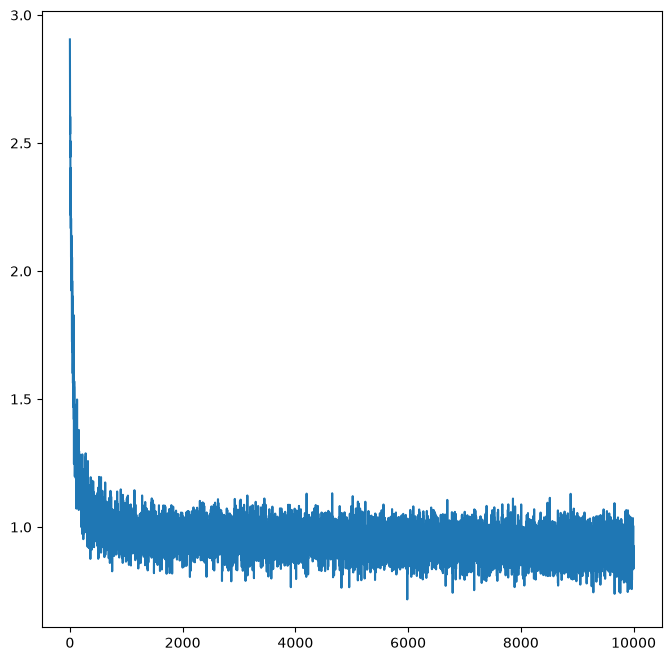

In [84]:
emb_2d_model.plot_log_loss()

In [85]:
emb_2d_model.forward(X_test, Y_test).item()

2.5289089679718018

### 2D embedding visualization

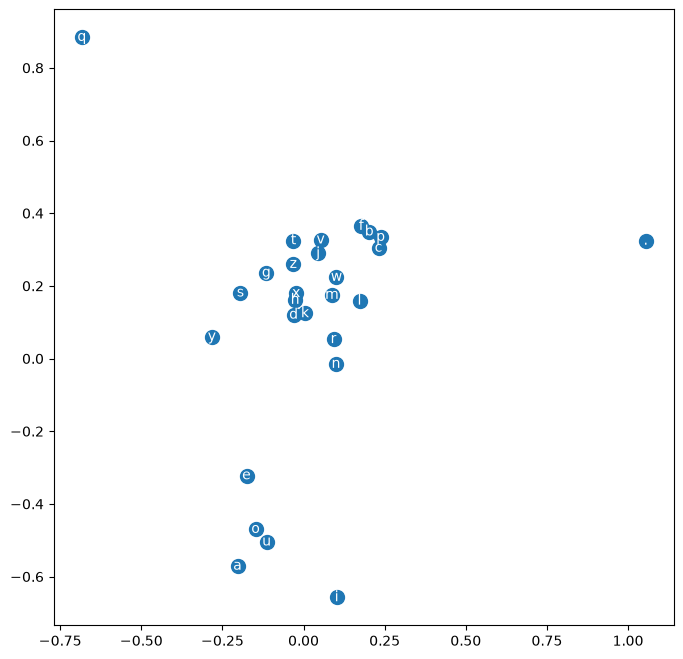

In [86]:
def visualize_2d_embedding(emb):
    plt.figure(figsize=(8, 8))
    plt.scatter(
        x=emb[:, 0].tolist(),
        y=emb[:, 1].tolist(),
        s=100,
    )
    for i in range(N_CHARS):
        plt.text(
            x=emb[i, 0].item(),
            y=emb[i, 1].item(),
            s=itos[i],
            color="white",
            va="center",
            ha="center",
        )

visualize_2d_embedding(emb_2d_model.embeddings)

### Trying to beat bigram model (lowest loss = 2.5106)

In [87]:
PREV_TOKENS = 3

X_train, Y_train = encode_words(words[:a], PREV_TOKENS)
X_valid, Y_valid = encode_words(words[a:b], PREV_TOKENS)
X_test, Y_test = encode_words(words[b:], PREV_TOKENS)

In [88]:
best_model = MLP(
    token_dim=N_CHARS,
    embedding_dim=10,
    prev_tokens=PREV_TOKENS,
    hidden_dim=200,
    output_dim=N_CHARS,
)

In [89]:
best_model.fit(
    X_train,
    Y_train,
    batch_size=128,
    learning_rate=0.1,
    epochs=20_000,
)

1    : loss = 25.70688247680664
101  : loss = 8.256689071655273
201  : loss = 7.242716312408447
301  : loss = 5.861719131469727
401  : loss = 4.815118789672852
501  : loss = 3.998783826828003
601  : loss = 3.8426473140716553
701  : loss = 3.3304269313812256
801  : loss = 3.565200090408325
901  : loss = 2.64495849609375
1001 : loss = 3.162626266479492
1101 : loss = 3.469913959503174
1201 : loss = 3.163741111755371
1301 : loss = 2.8393850326538086
1401 : loss = 2.960766315460205
1501 : loss = 2.9162919521331787
1601 : loss = 2.881582736968994
1701 : loss = 2.692276954650879
1801 : loss = 2.8788235187530518
1901 : loss = 2.514223337173462
2001 : loss = 2.785954236984253
2101 : loss = 2.689227819442749
2201 : loss = 2.5138795375823975
2301 : loss = 2.584946870803833
2401 : loss = 2.601923704147339
2501 : loss = 2.731436252593994
2601 : loss = 2.6955854892730713
2701 : loss = 2.8648996353149414
2801 : loss = 2.8105311393737793
2901 : loss = 2.785203456878662
3001 : loss = 2.6343793869018555

In [98]:
best_model.fit(
    X_train,
    Y_train,
    batch_size=128,
    learning_rate=0.001,
    epochs=10_000,
)

1    : loss = 2.0939042568206787
101  : loss = 2.314338445663452
201  : loss = 2.216754674911499
301  : loss = 2.3691773414611816
401  : loss = 2.3857293128967285
501  : loss = 2.2792060375213623
601  : loss = 2.170501470565796
701  : loss = 2.3830249309539795
801  : loss = 2.383059501647949
901  : loss = 2.3402810096740723
1001 : loss = 2.203538417816162
1101 : loss = 2.1840415000915527
1201 : loss = 2.1135146617889404
1301 : loss = 2.393054723739624
1401 : loss = 2.0867867469787598
1501 : loss = 2.192885398864746
1601 : loss = 2.1334280967712402
1701 : loss = 2.14035964012146
1801 : loss = 2.315519332885742
1901 : loss = 2.4813618659973145
2001 : loss = 2.2695043087005615
2101 : loss = 2.397383689880371
2201 : loss = 2.2469029426574707
2301 : loss = 2.1212656497955322
2401 : loss = 2.2052536010742188
2501 : loss = 2.2385199069976807
2601 : loss = 2.340742349624634
2701 : loss = 2.578148126602173
2801 : loss = 2.3511135578155518
2901 : loss = 2.1554274559020996
3001 : loss = 2.1965062

In [99]:
best_model.forward(X_test, Y_test).item()

2.3118996620178223

mission accomplished :)

### Visualize N-dim embedding with PCA

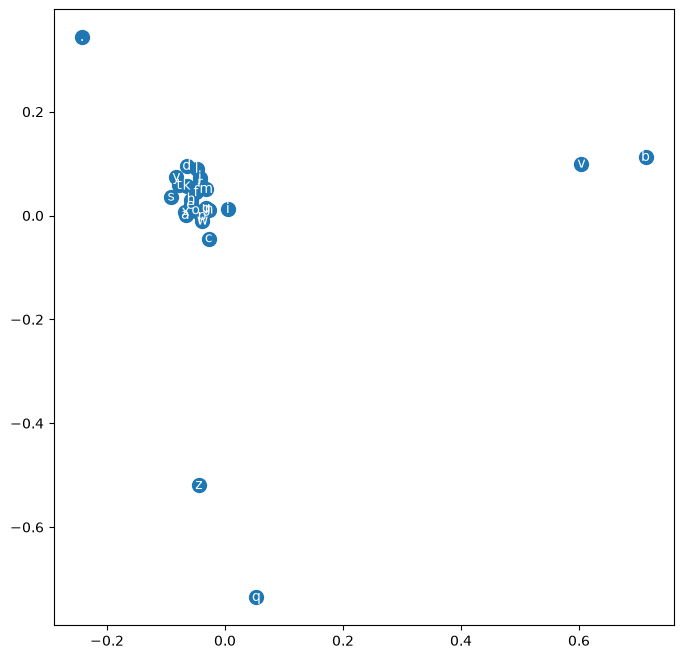

In [100]:
U, _S, _V = torch.pca_lowrank(best_model.embeddings, 2)
visualize_2d_embedding(U)

# Lets generate some words

In [101]:
WORDS = 5
MAX_WORD_LEN = 20

In [ ]:
GEN = torch.Generator().manual_seed(42)


for _ in range(WORDS):
    block = [0, 0, 0]
    word = ""
    for _ in range(MAX_WORD_LEN):
        next_pred = best_model.predict(torch.tensor(block))
        probs = next_pred.softmax(dim=1)
        next_char_i = int(torch.multinomial(probs, num_samples=1, replacement=True, generator=GEN).item())
        if next_char_i == stoi["."]:
            break
        word += itos[next_char_i]
        block = block[1:] + [next_char_i]
    print(word)

coundenve
smaabidushyems
strifa
ind
cots
